Saving Behavioural Finance Experiment - experiment_data.csv to Behavioural Finance Experiment - experiment_data (1).csv

Overall proportion of subjects in study 1 choosing risky option: 0.48

Proportion of subjects in study 1 choosing the risky option for each frame:
Frame
Gain    0.307
Loss    0.653
Name: risky_choice, dtype: float64

Proportion of subjects in study 1 choosing the risky option based on confidence level:
Confidence_Rating
4     0.000
5     0.682
6     0.500
7     0.550
8     0.333
9     0.200
10    0.500
Name: risky_choice, dtype: float64

Proportion of subjects in study 1 choosing the risky option for each level of self-proclaimed financial literacy:
Financial_Literacy
High      0.52
Low       0.50
Medium    0.42
Name: risky_choice, dtype: float64


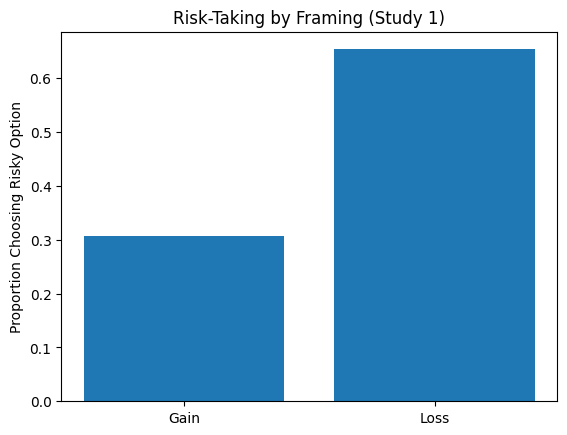

Saving Finance Professional Experiment Data.csv to Finance Professional Experiment Data (1).csv

Overall proportion of subjects in study 2 choosing risky option: 0.453

Proportion of subjects in study 2 choosing the risky option for each frame:
Frame
Gain    0.360
Loss    0.547
Name: risky choice, dtype: float64

Proportion of subjects in study 2 choosing the risky option for each level of experience:
Years_of_Experience
0–2     0.610
3–5     0.326
6–10    0.417
10+     0.467
Name: risky choice, dtype: float64


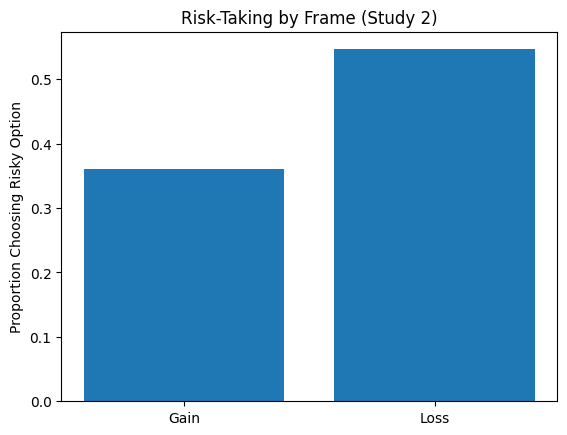

<Figure size 640x480 with 0 Axes>

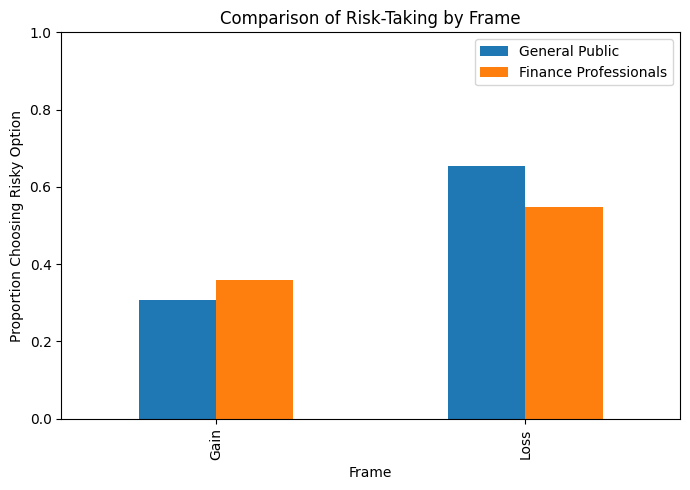

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Analysis of results from the first study conducted on the general public

from google.colab import files
uploaded = files.upload()
df_study1 = pd.read_csv("Behavioural Finance Experiment - experiment_data.csv")

# Encode risky choice
df_study1["risky_choice"] = df_study1["Choice"].apply(lambda x: 1 if x.lower() == "risky" else 0)

# Calculate overall risk-taking proportion
overall_risk = df_study1["risky_choice"].mean()
print("\nOverall proportion of subjects in study 1 choosing risky option:", round(overall_risk, 3))

# Framing effect analysis
print("\nProportion of subjects in study 1 choosing the risky option for each frame:")
print(df_study1.groupby("Frame")["risky_choice"].mean().round(3))

# Confidence level analysis
print("\nProportion of subjects in study 1 choosing the risky option based on confidence level:")
print(df_study1.groupby("Confidence_Rating")["risky_choice"].mean().round(3))

# Financial literacy analysis
print("\nProportion of subjects in study 1 choosing the risky option for each level of self-proclaimed financial literacy:")
print(df_study1.groupby("Financial_Literacy")["risky_choice"].mean().round(3))

# Bar Chart for study 1 results
plt.figure() # Create a new figure
study1_frame_data = df_study1.groupby("Frame")["risky_choice"].mean()
plt.bar(study1_frame_data.index, study1_frame_data.values)
plt.ylabel("Proportion Choosing Risky Option")
plt.title("Risk-Taking by Framing (Study 1)")
plt.show()

# Analysis of results from the second study conducted on finance professionals

from google.colab import files
uploaded = files.upload()
df_study2 = pd.read_csv ("Finance Professional Experiment Data.csv")

# Encode risky choice
df_study2["risky choice"] = df_study2["Choice"].apply(lambda x: 1 if x.lower() == "risky" else 0)

# Calculate overall risk-taking proportion
overall_risk = df_study2["risky choice"].mean()
print("\nOverall proportion of subjects in study 2 choosing risky option:", round(overall_risk, 3))

# Framing effect analysis
print("\nProportion of subjects in study 2 choosing the risky option for each frame:")
print(df_study2.groupby("Frame")["risky choice"].mean().round(3))

# Years of experience effect analysis
experience_order = ["0–2", "3–5", "6–10", "10+"]
df_study2["Years_of_Experience"] = pd.Categorical(df_study2["Years_of_Experience"], categories=experience_order, ordered=True)
print("\nProportion of subjects in study 2 choosing the risky option for each level of experience:")
print(df_study2.groupby("Years_of_Experience")["risky choice"].mean().round(3))

# Bar Chart for Study 2 results
plt.figure()
study2_frame_data = df_study2.groupby("Frame")["risky choice"].mean()
plt.bar(study2_frame_data.index, study2_frame_data.values)
plt.ylabel("Proportion Choosing Risky Option")
plt.title("Risk-Taking by Frame (Study 2)")
plt.show()

# Bar chart for comparison of results
plt.figure()
study1 = df_study1.groupby("Frame")["risky_choice"].mean()
study2 = df_study2.groupby("Frame")["risky choice"].mean()
comparison = pd.DataFrame({"General Public": study1, "Finance Professionals": study2})
# Using .plot.bar() directly on the DataFrame is generally fine, but we can also use plt.bar for more control.
# For comparison, keeping it as is, or we could refactor similarly.
# For now, let's keep this as it often doesn't trigger the same warnings due to being directly on a DataFrame.
comparison.plot(kind="bar", figsize=(7,5))
plt.ylabel("Proportion Choosing Risky Option")
plt.xlabel("Frame")
plt.title("Comparison of Risk-Taking by Frame")
plt.ylim(0,1)
plt.legend(title="")
plt.tight_layout()
plt.show()